<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 8</b></center>    
<pre>    

# import necessary libraries

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Import diabetes.csv dataset using sklearn

In [2]:
df = pd.read_csv('diabetes.csv')

In [20]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50,Diabetic
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31,Non Diabetic
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32,Diabetic
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21,Non Diabetic
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33,Diabetic
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.00000,180.000000,32.9,0.171,63,Non Diabetic
764,2,122.0,70.0,27.00000,155.548223,36.8,0.340,27,Non Diabetic
765,5,121.0,72.0,23.00000,112.000000,26.2,0.245,30,Non Diabetic
766,1,126.0,60.0,29.15342,155.548223,30.1,0.349,47,Diabetic


# Check the distribution of the target

In [21]:
df['Outcome'].value_counts()

Outcome
Non Diabetic    500
Diabetic        268
Name: count, dtype: int64

# Replace zeros with NaN for specific columns

In [22]:
# Count how many zero values each column has
(df == 0).sum()

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [23]:
# Pregnancies is allowed to be 0
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [24]:
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

In [25]:
(df == 0).sum()

Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

# Check for missing values

In [26]:
# Verify the zeros were converted to NaN
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# Fill missing values with median

In [27]:
# Fill missing values in each column with that column's median
for col in cols_with_zero:
    df[col] = df[col].fillna(df[col].median())

In [28]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# Visualize Distributions

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')

In [ ]:
df.plot(kind='box', subplots=True, layout=(3, 3), figsize=(14, 10))
plt.tight_layout()
plt.show()

# Convert Targer data into interger code

In [33]:
df['Outcome'] = df['Outcome'].map({'Diabetic': 1, 'Non Diabetic': 0})

In [ ]:
df

# Divide the data into input and output

In [35]:
x = df.drop('Outcome', axis=1)
y = df['Outcome']

# Splitting the dataset into the Training set and Test set

In [52]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, 
                        test_size=0.3, random_state=42,stratify=y)

# Create Model

In [74]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=2)

# Fitting DecisionTreeClassifier   on dataset

In [75]:
model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=2)

# Display Decision Tree

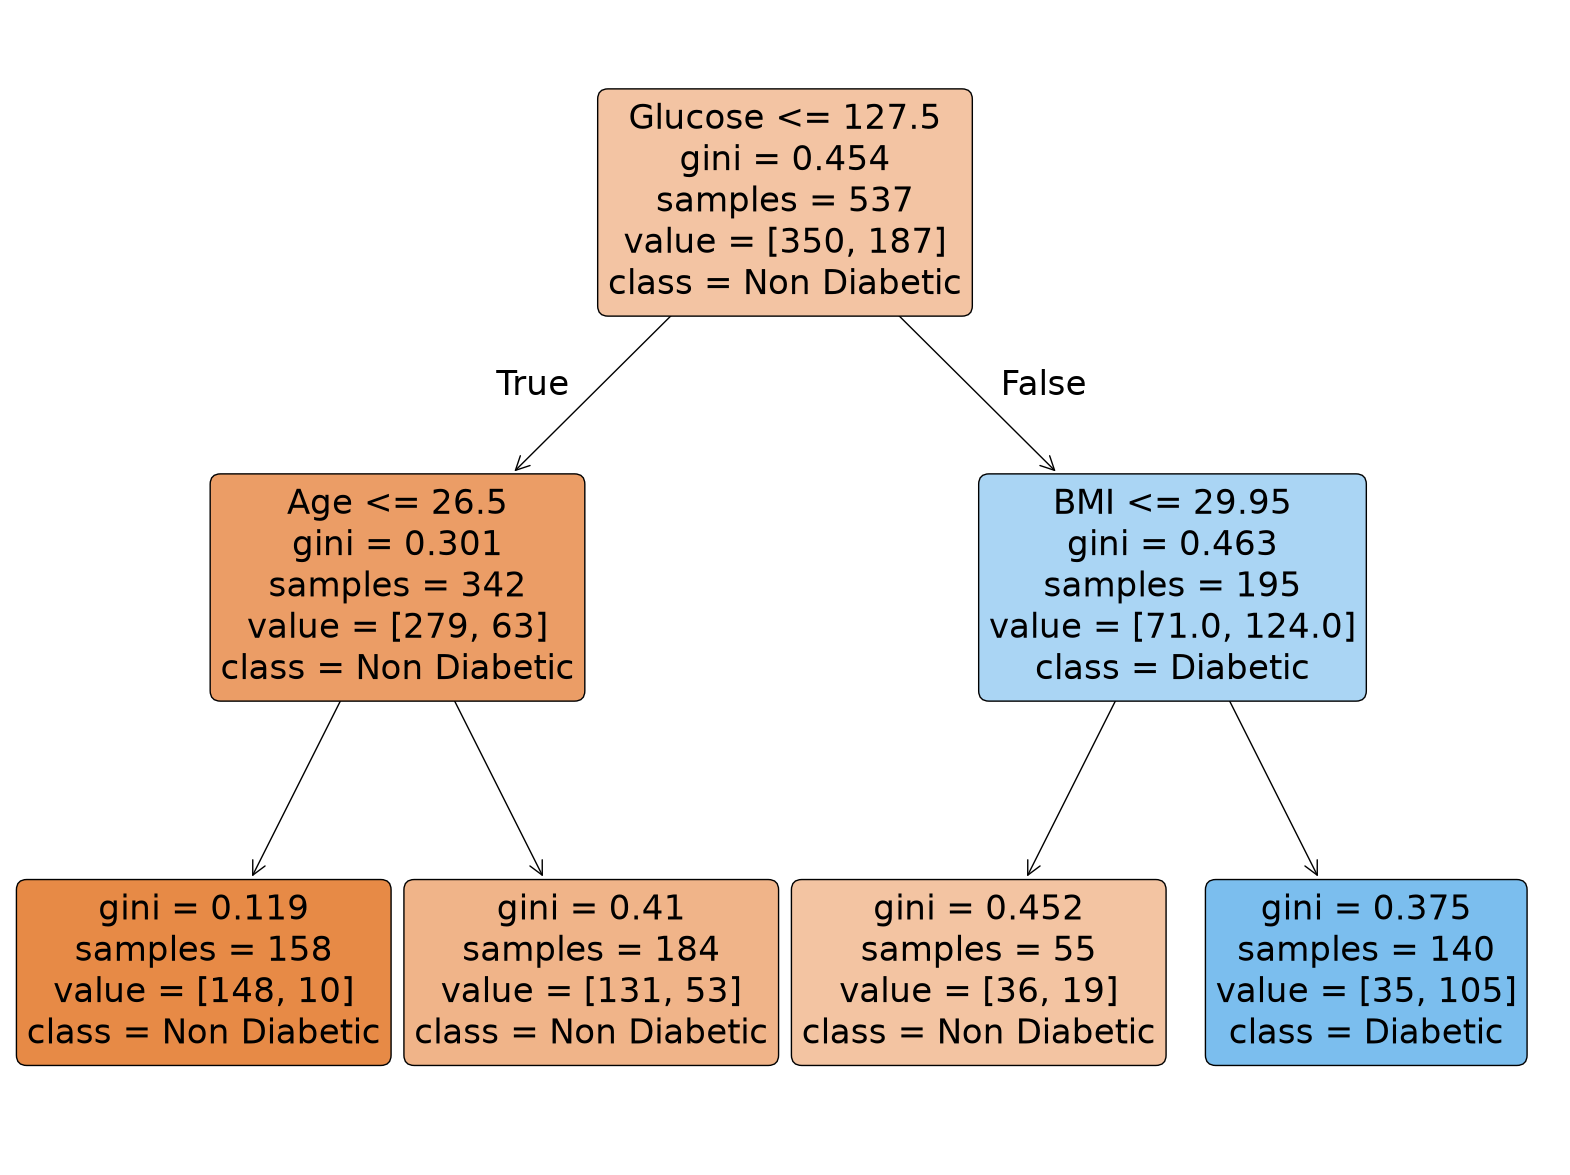

In [76]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,15))
plot_tree(model, 
          feature_names=x.columns, 
          class_names=['Non Diabetic', 'Diabetic'], 
          filled=True,rounded=True)
plt.show()


# Predict the x_test 

In [77]:
y_pred = model.predict(x_test)
y_pred

array([0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0])

# Display Training Accuracy

In [78]:
model.score(x_train,y_train)

0.7821229050279329

# Display Test Accuracy

In [79]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test,y_pred)
acc

0.7445887445887446

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

In [ ]:
print('Classification Report:')
print(classification_report(y_test, y_pred))

In [67]:
macc,md=0,0
for j in range(0,100):
    from sklearn.model_selection import train_test_split
    x_train, x_test, y_train, y_test = train_test_split(x, y, 
                            test_size=0.3,random_state=j,stratify=y)

    for i in range(1,11):
        from sklearn.tree import DecisionTreeClassifier
        model = DecisionTreeClassifier(max_depth=i)
        
        model.fit(x_train, y_train)
        y_pred = model.predict(x_test)
        acc = accuracy_score(y_test,y_pred)
        if acc>macc:
            macc = acc
            md = i
    print(f"For {j} random state,depth = {md} => Max Accuracy = {macc}")

For 0 random state,depth = 1 => Max Accuracy = 0.7489177489177489
For 1 random state,depth = 6 => Max Accuracy = 0.7575757575757576
For 2 random state,depth = 5 => Max Accuracy = 0.7705627705627706
For 3 random state,depth = 5 => Max Accuracy = 0.7705627705627706
For 4 random state,depth = 5 => Max Accuracy = 0.7705627705627706
For 5 random state,depth = 5 => Max Accuracy = 0.7705627705627706
For 6 random state,depth = 5 => Max Accuracy = 0.8008658008658008
For 7 random state,depth = 5 => Max Accuracy = 0.8008658008658008
For 8 random state,depth = 5 => Max Accuracy = 0.8008658008658008
For 9 random state,depth = 5 => Max Accuracy = 0.8008658008658008
For 10 random state,depth = 5 => Max Accuracy = 0.8008658008658008
For 11 random state,depth = 6 => Max Accuracy = 0.8138528138528138
For 12 random state,depth = 6 => Max Accuracy = 0.8138528138528138
For 13 random state,depth = 6 => Max Accuracy = 0.8138528138528138
For 14 random state,depth = 6 => Max Accuracy = 0.8138528138528138
For 1